# Random Forest Hyperparameter Tuning
Grid search with 5-fold cross validation on the train set to find the best Random Forest parameters.
Scored on ROC AUC to prioritise correct identification of murmur-present recordings.
Best model is retrained on full train set and evaluated once on the held-out test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

PROJECT_ROOT = Path(r"D:\sop")
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
MODELS_DIR   = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
matplotlib.rcParams.update({"font.size": 9})

print("Ready.")

Ready.


In [2]:
# loading train and test splits

train = pd.read_csv(SPLITS_DIR / "train.csv")
test  = pd.read_csv(SPLITS_DIR / "test.csv")

FEATURE_COLS = [c for c in train.columns if c not in ["file", "class"]]

X_train = train[FEATURE_COLS].values
y_train = (train["class"] == "present").astype(int).values

X_test  = test[FEATURE_COLS].values
y_test  = (test["class"] == "present").astype(int).values

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Features: {len(FEATURE_COLS)}")

Train: (3785, 25)  Test: (997, 25)
Features: 25


In [3]:
# baseline performance for comparison
# loading the default model trained in block 10

baseline_rf  = joblib.load(MODELS_DIR / "random_forest.joblib")
base_pred    = baseline_rf.predict(X_test)
base_prob    = baseline_rf.predict_proba(X_test)[:, 1]
base_acc     = accuracy_score(y_test, base_pred)
base_auc     = roc_auc_score(y_test, base_prob)

print("Baseline (default parameters):")
print(f"  Accuracy : {base_acc:.4f}  ({base_acc*100:.2f}%)")
print(f"  ROC AUC  : {base_auc:.4f}")
print(f"  Params   : n_estimators=300, min_samples_leaf=5, max_depth=None, max_features=sqrt")

Baseline (default parameters):
  Accuracy : 0.6510  (65.10%)
  ROC AUC  : 0.7011
  Params   : n_estimators=300, min_samples_leaf=5, max_depth=None, max_features=sqrt


In [4]:
# defining the parameter grid
# each combination will be evaluated using 5-fold cross validation on the train set
# total combinations: 4 x 4 x 4 x 3 = 192 fits x 5 folds = 960 fits

param_grid = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [None, 10, 20, 30],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features"    : ["sqrt", "log2", 0.5],
}

total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Parameter combinations : {total}")
print(f"Total fits (x5 folds)  : {total * 5}")

Parameter combinations : 192
Total fits (x5 folds)  : 960


In [5]:
# running grid search
# scoring on roc_auc to prioritise separating present from absent
# n_jobs=-1 uses all CPU cores
# this cell will take several minutes to run

rf_base = RandomForestClassifier(
    class_weight = "balanced",
    random_state = RANDOM_STATE,
    n_jobs       = -1
)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    scoring    = "roc_auc",
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)
print("\nGrid search complete.")
print(f"Best ROC AUC (cross-val): {grid_search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

Grid search complete.
Best ROC AUC (cross-val): 0.6909
Best parameters:
  max_depth: 10
  max_features: log2
  min_samples_leaf: 20
  n_estimators: 500


In [6]:
# top 10 parameter combinations by cross-val ROC AUC

cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.sort_values("mean_test_score", ascending=False).head(10)[
    ["param_n_estimators", "param_max_depth", "param_min_samples_leaf",
     "param_max_features", "mean_test_score", "std_test_score"]
].reset_index(drop=True)

print("Top 10 combinations:")
print(top10.to_string(index=False))

Top 10 combinations:
 param_n_estimators param_max_depth  param_min_samples_leaf param_max_features  mean_test_score  std_test_score
                500              10                      20               log2         0.690913        0.086199
                200              10                      20               log2         0.690825        0.086535
                500              10                      20               sqrt         0.690011        0.087505
                300              10                      20               log2         0.689775        0.085960
                100              10                      20               log2         0.689707        0.086876
                200              10                      20                0.5         0.689679        0.085475
                100              10                      20               sqrt         0.689583        0.084860
                100              10                      20                0.5     

In [7]:
# evaluating the best model on the test set
# grid search already retrains on full train set internally (refit=True by default)

best_rf   = grid_search.best_estimator_
y_pred = (best_rf.predict_proba(X_test)[:, 1] >= 0.35).astype(int)
y_prob    = best_rf.predict_proba(X_test)[:, 1]

tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob)

print("Tuned model (test set):")
print(f"  Accuracy : {tuned_acc:.4f}  ({tuned_acc*100:.2f}%)")
print(f"  ROC AUC  : {tuned_auc:.4f}")
print(f"\nImprovement over baseline:")
print(f"  Accuracy : {(tuned_acc - base_acc)*100:+.2f}%")
print(f"  ROC AUC  : {tuned_auc - base_auc:+.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["absent", "present"]))

Tuned model (test set):
  Accuracy : 0.6038  (60.38%)
  ROC AUC  : 0.7040

Improvement over baseline:
  Accuracy : -4.71%
  ROC AUC  : +0.0029

Classification report:
              precision    recall  f1-score   support

      absent       0.67      0.41      0.51       497
     present       0.58      0.80      0.67       500

    accuracy                           0.60       997
   macro avg       0.62      0.60      0.59       997
weighted avg       0.62      0.60      0.59       997



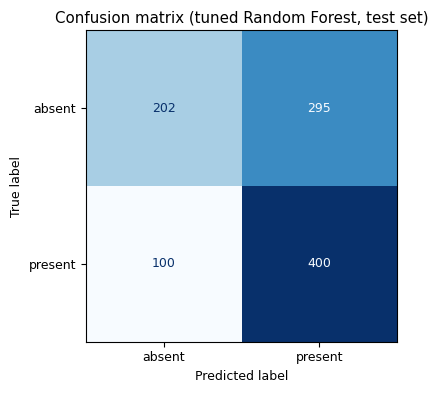

Saved: D:\sop\outputs\rf_tuned_confusion_matrix.png

True negatives  (absent correctly identified) : 202
False positives (absent called present)        : 295
False negatives (present missed)               : 100
True positives  (present correctly identified) : 400


In [8]:
# confusion matrix for tuned model

cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["absent", "present"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix (tuned Random Forest, test set)")
plt.tight_layout()
out = OUTPUTS_DIR / "rf_tuned_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue negatives  (absent correctly identified) : {tn}")
print(f"False positives (absent called present)        : {fp}")
print(f"False negatives (present missed)               : {fn}")
print(f"True positives  (present correctly identified) : {tp}")

In [9]:
# baseline vs tuned side by side comparison

base_cm = confusion_matrix(y_test, base_pred)
base_tn, base_fp, base_fn, base_tp = base_cm.ravel()
tuned_tn, tuned_fp, tuned_fn, tuned_tp = cm.ravel()

comparison = pd.DataFrame({
    "metric"          : ["Accuracy", "ROC AUC", "Present recall", "Present precision", "Absent recall", "False negatives (missed murmurs)"],
    "baseline"        : [
        f"{base_acc*100:.2f}%",
        f"{base_auc:.4f}",
        f"{base_tp/(base_tp+base_fn)*100:.2f}%",
        f"{base_tp/(base_tp+base_fp)*100:.2f}%",
        f"{base_tn/(base_tn+base_fp)*100:.2f}%",
        f"{base_fn}"
    ],
    "tuned"           : [
        f"{tuned_acc*100:.2f}%",
        f"{tuned_auc:.4f}",
        f"{tuned_tp/(tuned_tp+tuned_fn)*100:.2f}%",
        f"{tuned_tp/(tuned_tp+tuned_fp)*100:.2f}%",
        f"{tuned_tn/(tuned_tn+tuned_fp)*100:.2f}%",
        f"{tuned_fn}"
    ]
})

print(comparison.to_string(index=False))

                          metric baseline  tuned
                        Accuracy   65.10% 60.38%
                         ROC AUC   0.7011 0.7040
                  Present recall   51.60% 80.00%
               Present precision   70.88% 57.55%
                   Absent recall   78.67% 40.64%
False negatives (missed murmurs)      242    100


In [10]:
# saving the tuned model

model_out = MODELS_DIR / "random_forest_tuned.joblib"
joblib.dump(best_rf, model_out)
print(f"Saved: {model_out}")

Saved: D:\sop\models\random_forest_tuned.joblib
